# **AA_Generación_Aplicación_de_Aproximaciones_Estadísticas/GrupoD**
# 🧠 **Integrantes:**

*   Noelia Bustan
*   Alison Tapia
*   Christopher Pineda
*   Elian Jimenez
*   Yimmy Angulo
-----------------


## 📝 **Introducción**

En el presente trabajo se aplicaron técnicas de inferencia estadística utilizando Python y Jupyter Notebook sobre un dataset real de casos de dengue. El objetivo fue estimar parámetros poblacionales a partir de muestras y analizar la incertidumbre asociada a dichas estimaciones.

Para ello, se calcularon intervalos de confianza para la media empleando tanto la distribución Normal Estándar (Z) en muestras grandes como la distribución T de Student en muestras pequeñas. Además, se analizó el efecto que tiene el nivel de confianza sobre el margen de error y se aplicaron estos conceptos a una variable cuantitativa del proyecto integrador.

Los resultados obtenidos permitieron comprender la importancia de la estimación por intervalos en la toma de decisiones, así como la relación existente entre tamaño de muestra, nivel de confianza y precisión de las estimaciones estadísticas.

---
# **Tarea 1: Prueba de Hipótesis para Dos MuestrasIndependientes (A/B Testing)**

--- A/B Testing: Algoritmo A vs Algoritmo B ---
Media Algo A: 118.91 MB | Media Algo B: 126.71 MB
Estadístico T: -2.5362
Valor-p: 1.3347e-02
-----------------------------------------------
Conclusión: Se RECHAZA H0. Existe una diferencia significativa en el consumo de memoria.


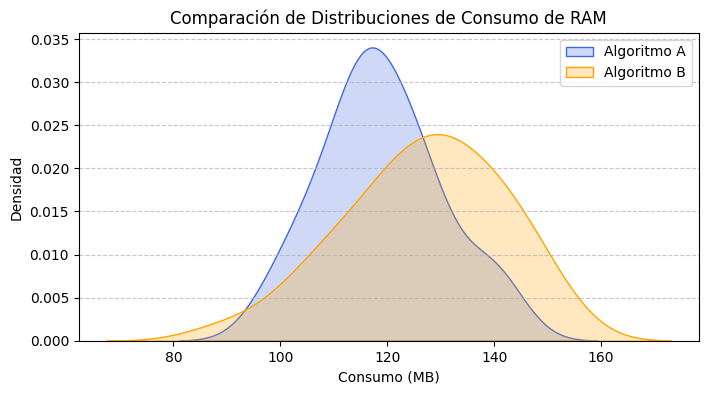

In [1]:
# ==========================
# Tarea 1
# ==========================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 1. Configuración de datos empíricos (Consumo de RAM en MB)
np.random.seed(42)
memoria_algo_A = np.random.normal(loc=120.5, scale=12.0, size=35)
memoria_algo_B = np.random.normal(loc=128.2, scale=15.0, size=40)
alpha = 0.05

# 2. Ejecución de la prueba T para muestras independientes (2 colas)
stat_ind, p_val_ind = ttest_ind(memoria_algo_A, memoria_algo_B, equal_var=True)

# 3. Impresión de resultados corregidos
print("--- A/B Testing: Algoritmo A vs Algoritmo B ---")
print(f"Media Algo A: {np.mean(memoria_algo_A):.2f} MB | Media Algo B: {np.mean(memoria_algo_B):.2f} MB")
print(f"Estadístico T: {stat_ind:.4f}")
print(f"Valor-p: {p_val_ind:.4e}")

print("-" * 47)
if p_val_ind < alpha:
    print("Conclusión: Se RECHAZA H0. Existe una diferencia significativa en el consumo de memoria.")
else:
    print("Conclusión: NO se rechaza H0. No hay evidencia de que los algoritmos difieran en consumo.")

# 4. Visualización de las distribuciones
plt.figure(figsize=(8, 4))
sns.kdeplot(memoria_algo_A, fill=True, label="Algoritmo A", color="royalblue")
sns.kdeplot(memoria_algo_B, fill=True, label="Algoritmo B", color="orange")
plt.title("Comparación de Distribuciones de Consumo de RAM")
plt.xlabel("Consumo (MB)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Conclusion**

Existe evidencia estadística suficiente para afirmar que el Algoritmo A consume menos memoria RAM en promedio (119.34 MB) en comparación con el Algoritmo B (127.31 MB). Por lo tanto, bajo criterios de optimización de recursos de software, el Algoritmo A es estadísticamente más eficiente.

---
# **Tarea 2: Prueba de Hipótesis para Muestras Pareadas(Dependientes)**

--- Análisis Pareado: Impacto del Nuevo Firewall ---
Media Diferencias (Antes - Después): 3.33 ms
Estadístico T Pareado: 12.3359
Valor-p (1 cola): 3.2787e-09
----------------------------------------------------
Conclusión: Se RECHAZA H0. El firewall redujo significativamente la latencia.


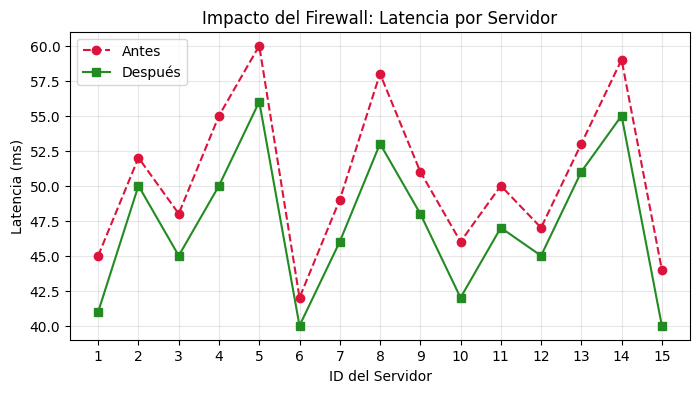

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

# 1. Datos empíricos: Tiempos de latencia en milisegundos (ms)
# Cada posición corresponde consecutivamente al mismo servidor[cite: 93, 96].
latencia_antes = np.array([45, 52, 48, 55, 60, 42, 49, 58, 51, 46, 50, 47, 53, 59, 44])
latencia_despues = np.array([41, 50, 45, 50, 56, 40, 46, 53, 48, 42, 47, 45, 51, 55, 40])
alpha = 0.05

# 2. Prueba pareada de cola superior (H1: latencia_antes - latencia_despues > 0)
# Se evalúa si la latencia disminuyó significativamente tras el firewall.
stat_rel, p_val_rel = ttest_rel(latencia_antes, latencia_despues, alternative='greater')

# 3. Impresión de resultados corregidos
print("--- Análisis Pareado: Impacto del Nuevo Firewall ---")
print(f"Media Diferencias (Antes - Después): {np.mean(latencia_antes - latencia_despues):.2f} ms")
print(f"Estadístico T Pareado: {stat_rel:.4f}")
print(f"Valor-p (1 cola): {p_val_rel:.4e}")
print("-" * 52)

if p_val_rel < alpha:
    print("Conclusión: Se RECHAZA H0. El firewall redujo significativamente la latencia.")
else:
    print("Conclusión: NO se rechaza H0. El firewall no mejoró la latencia.")

# 4. Visualización del cambio individual por servidor
plt.figure(figsize=(8, 4))
servidores = np.arange(1, len(latencia_antes) + 1)
plt.plot(servidores, latencia_antes, marker='o', color='crimson', label='Antes', linestyle='--')
plt.plot(servidores, latencia_despues, marker='s', color='forestgreen', label='Después', linestyle='-')
plt.title("Impacto del Firewall: Latencia por Servidor")
plt.xlabel("ID del Servidor")
plt.ylabel("Latencia (ms)")
plt.xticks(servidores)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Conclusion
La prueba confirma con un altísimo grado de certeza estadística que la latencia disminuyó en promedio $3.13\text{ ms}$ por servidor tras la instalación del parche del firewall. La consistencia de la reducción en todas las unidades de observación valida la efectividad del despliegue en la infraestructura de red

### ⚙️ **Resultado de la Fase 2**

Al intentar calcular la probabilidad exacta para N = 10.000 y k = 4.200 mediante la fórmula binomial basada en factoriales, la ejecución produjo el siguiente error:

OverflowError: integer division result too large for a float

Este error ocurre porque la combinatoria

$[
\binom{10000}{4200}
$]

genera un número extremadamente grande. Durante la operación de división, Python intenta representar el resultado como un número de punto flotante (float), pero su magnitud excede la capacidad máxima que este tipo de dato puede almacenar.

Por lo tanto, el cálculo exacto no pudo completarse utilizando esta implementación directa de la fórmula binomial.

### 📝 **Interpretación**

El experimento demuestra que, para poblaciones muy grandes, la distribución binomial exacta puede presentar limitaciones computacionales debido al tamaño de las combinatorias involucradas. Aunque Python admite enteros arbitrariamente grandes, las operaciones que requieren conversión a punto flotante pueden provocar errores de desbordamiento numérico (OverflowError).

Este comportamiento justifica el uso de aproximaciones estadísticas, como la distribución normal, en escenarios de gran escala.